# <p align  = "center"> Data Sizes Analysis </p>

In [1]:
#Initialize Notebook Environment
from pathlib import Path
import sys
sys.path.insert( 0, Path("../..").resolve().absolute().__str__() )

- Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xaidar.filesUtils import loadPickle

xc_dataDir = Path( "../../../data/s3Sizes/xchem/filetypes" )
xc_dataStats = loadPickle( xc_dataDir / "stats_filetype_sizes.pkl" )
xc_dataStats_df = pd.DataFrame( xc_dataStats )

pd_dataDir = Path( "../../../data/s3Sizes/pandda/filetypes" )
pd_dataStats = loadPickle( pd_dataDir / "stats_filetype_sizes.pkl" )
pd_dataStats_df = pd.DataFrame( pd_dataStats )

print( "XChem Data Statistics:" )
display( xc_dataStats_df.head(2))
print( "Pandda Data Statistics:" )
display( pd_dataStats_df.head(2) )


XChem Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,492956,1860.0,13679.315385,3.242432e+05,1356.0,3357.0,1000.5,80906623,0,6743300595
1,.txt,3458488,10672.0,304168.266793,3.178951e+06,1380.0,25226.0,11923.0,487143107,0,1051962300685


Pandda Data Statistics:


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.csv,168,61908.0,239908.482143,489547.716090,23280.75,228948.0,102833.625,3606844,3,40304625
1,.log,608435,9143.0,20228.220240,22693.793181,738.00,39411.0,19336.500,309100,0,12307557182


In [3]:
# Table Hihgest Sum
print( "Top 2 File Types by Sum Size in XChem:" )
display( xc_dataStats_df.sort_values(by=[ "Sum", "Files Count",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2] )
print( "Top 2 File Types by Sum Size in Pandda:" )
display( pd_dataStats_df.sort_values(by=[ "Sum", "Files Count",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])

Top 2 File Types by Sum Size in XChem:


,File Type,Sum,Files Count
337,.ccp4,43335563627385,2007939
11,.mtz,37612329367516,7623701


Top 2 File Types by Sum Size in Pandda:


,File Type,Sum,Files Count
7,.ccp4,7791652589728,900842
8,.mtz,336014350808,96111


In [ ]:
# Table Highest Count
print( "Top 2 File Types by Count in XChem:" )
display( xc_dataStats_df.sort_values(by=[ "Files Count", "Sum",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])
print( "Top 2 File Types by Count in Pandda:" )
display( pd_dataStats_df.sort_values(by=[ "Files Count", "Sum",], ascending=[False, False])[["File Type", "Sum", "Files Count"]][:2])

Top 2 File Types by Count in XChem:


,File Type,Sum,Files Count
10,.pdb,2355704041649,22971408
6,.log,1627444661489,20414437


Top 2 File Types by Count in Pandda:


,File Type,Sum,Files Count
6,.pdb,264404634326,2053436
7,.ccp4,7791652589728,900842


- Totals Statisic Values

In [5]:
xc_bucketSize = xc_dataStats_df["Sum"].sum()
xc_bucketCount = xc_dataStats_df["Files Count"].sum()
# xc_bucketMedians = xc_dataStats_df["Median"].sum()

pd_bucketSize = pd_dataStats_df["Sum"].sum()
pd_bucketCount = pd_dataStats_df["Files Count"].sum()
# pandda_bucketMedians = pd_dataStats_df["Median"].sum()

print( "xchem Bucket Statistics:" )
print( f"\tTotal bucket size: {round( xc_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( xc_bucketCount / 1e6 , 2)} Million" )

print( "pandda Bucket Statistics:" )
print( f"\tTotal bucket size: {round( pd_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( pd_bucketCount / 1e6 , 2)} Million" )

xchem Bucket Statistics:
	Total bucket size: 156.15 TB
	Total files count: 129.66 Million
pandda Bucket Statistics:
	Total bucket size: 8.47 TB
	Total files count: 5.12 Million


- Per File Type Statistics

In [ ]:
# Filtering Odd Files
import re

xc_lstFileTypes = list(xc_dataStats_df["File Type"].values)

xc_removedFileTypes = [ file for file in list(xc_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ] 
xc_updatedFileTypes = [ file for file in list(xc_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

xc_removedFileTypes.extend( [ file for file in xc_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
xc_updatedFileTypes = [ file for file in xc_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]  


xc_updatedFileTypes = sorted( xc_updatedFileTypes)
xc_removedFileTypes = sorted( xc_removedFileTypes)

print(f"Number of File types after removing odds ones: {len(xc_updatedFileTypes)}")
print(f"Number of Removed File types: {len(xc_removedFileTypes)}")

pd_lstFileTypes = list(pd_dataStats_df["File Type"].values)

pd_removedFileTypes = [ file for file in list(pd_lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ]
pd_updatedFileTypes = [ file for file in list(pd_lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

pd_removedFileTypes.extend( [ file for file in pd_updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
pd_updatedFileTypes = [ file for file in pd_updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]

pd_updatedFileTypes = sorted( pd_updatedFileTypes)
pd_removedFileTypes = sorted( pd_removedFileTypes)

print(f"\nNumber of File types after removing odds ones: {len(pd_updatedFileTypes)}")
print(f"Number of Removed File types: {len(pd_removedFileTypes)}")
# # Displaying removed file types
# for i in range( len( removedFileTypes[:] )//20 ):
#     # print( removedFileTypes[i*20:(i+1)*20] )
#     print( removedFileTypes[-(i+1)*20: -i*20:] )

Number of File types after removing odds ones: 8875
Number of Removed File types: 257657
Number of File types after removing odds ones: 75
Number of Removed File types: 76


In [7]:
# Instantiate Objects to Plot
xc_sums =  xc_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
xc_counts =  xc_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 

pd_sums =  pd_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
pd_counts =  pd_dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 
# median = xc_dataStats_df.sort_values( by=[ "Median"], ascending=[False] ) 
pd_setRemovedFileTypes = set(pd_removedFileTypes)
pd_filteredsums = pd_dataStats_df[ ( [fileType not in pd_setRemovedFileTypes for fileType in  pd_dataStats_df["File Type"] ]  )].sort_values( by=[ "Sum"], ascending=[False] )
# filteredMedian = xc_dataStats_df[ ( [fileType not in setRemovedFileTypes for fileType in  xc_dataStats_df["File Type"] ]  )].sort_values( by=[ "Median"], ascending=[False] )

xchem Bucket Statistics:
	Total bucket size: 156.15 TB
	Total files count: 129.66 Million
pandda Bucket Statistics:
	Total bucket size: 8.47 TB
	Total files count: 5.12 Million


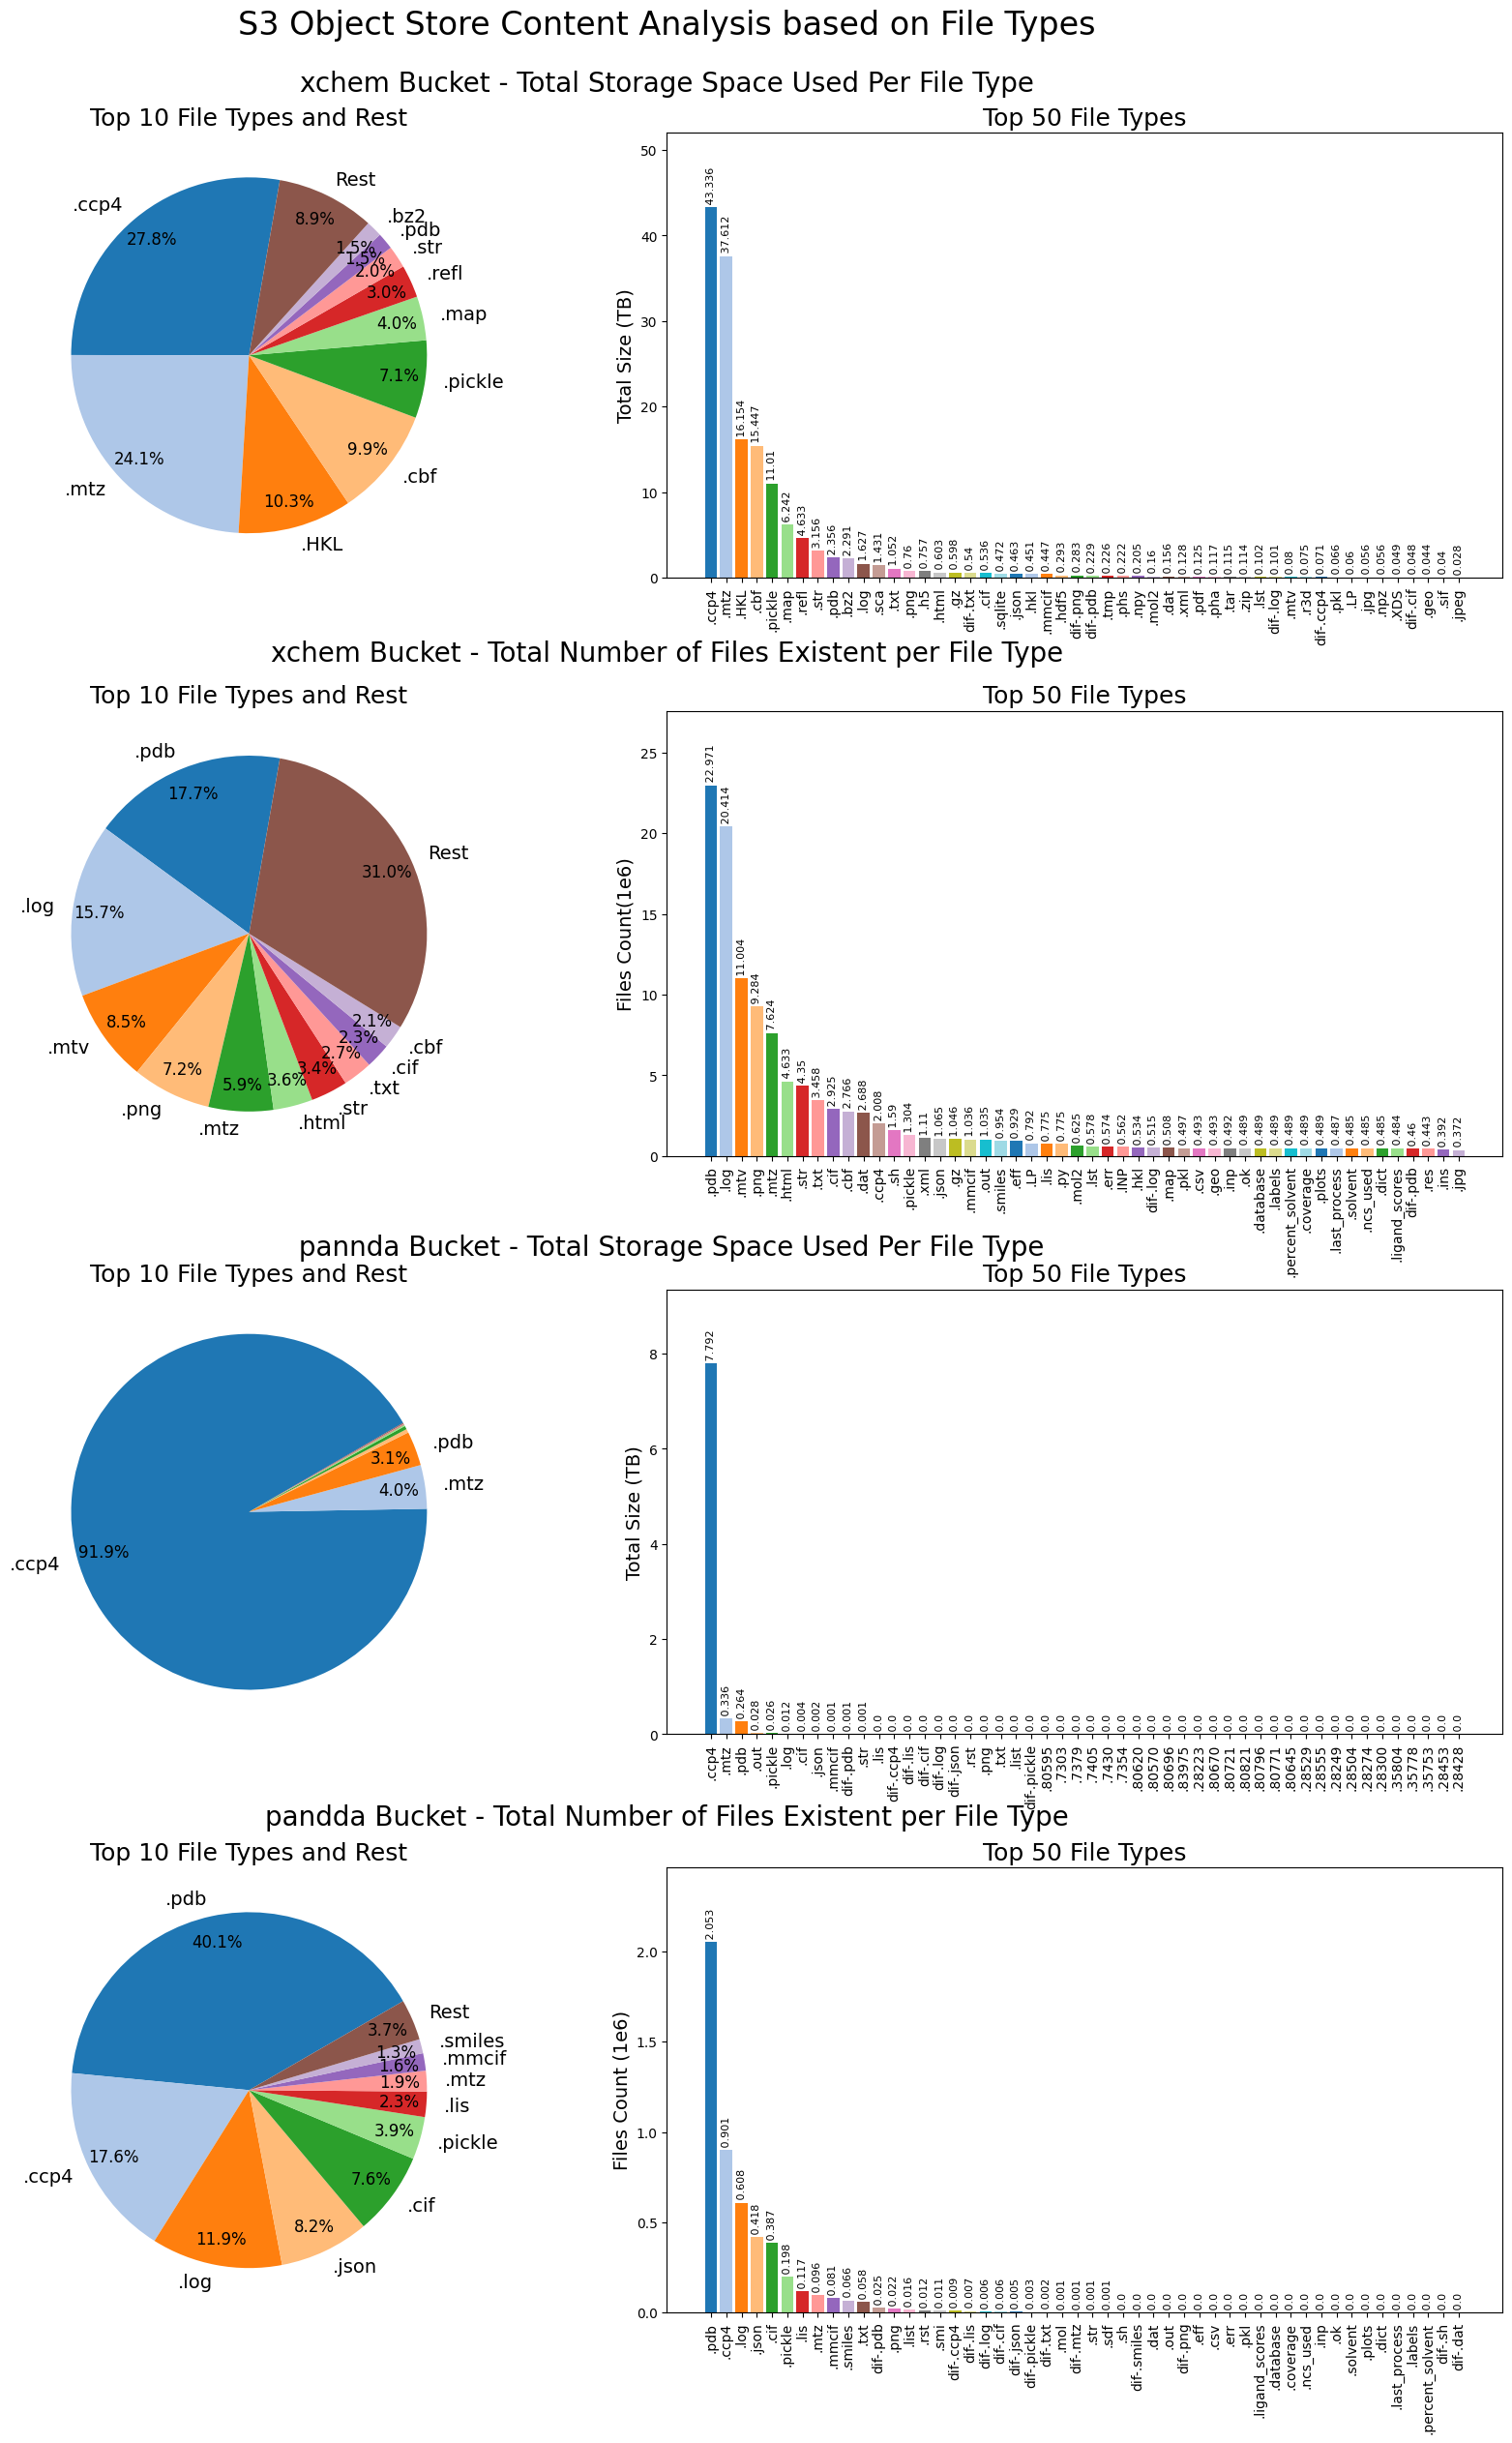

In [46]:
# Plotting the Data
import matplotlib.pyplot as plt
import seaborn as sns

print( "xchem Bucket Statistics:" )
print( f"\tTotal bucket size: {round( xc_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( xc_bucketCount / 1e6 , 2)} Million" )

print( "pandda Bucket Statistics:" )
print( f"\tTotal bucket size: {round( pd_bucketSize / 1e12, 2)} TB" )
print( f"\tTotal files count: {round( pd_bucketCount / 1e6 , 2)} Million" )

fig, ax = plt.subplots(4, 2, figsize=(24*0.8, 32*0.8))
# fig, ax = plt.subplots(2, 2, figsize=(24, 16))
# fig.tight_layout(h_pad=2)

sububSize = 18
axlabelSize = 14

wedges, texts, autotexts = ax[0,0].pie( list(xc_sums["Sum"][:10]) + [xc_bucketSize - sum(xc_sums["Sum"][:10])], labels= list(xc_sums["File Type"][:10] ) + ["Rest"],
            colors = sns.color_palette("tab20"), autopct='%1.1f%%', pctdistance=0.85,  startangle=80) #

for text in texts:
    text.set_fontsize(14) 

# Increase font size of the percentage labels (e.g., 15.0%, 30.0%)
for autotext in autotexts:
    autotext.set_fontsize(12) 

ax[0,0].set_title("Top 10 File Types and Rest", fontsize = sububSize)

scaledSum = [ round( sum / (1*10**12), 3) for sum in xc_sums["Sum"][:50]]
ax[0,1].bar(xc_sums["File Type"][:50], scaledSum, color=sns.color_palette("tab20"))
ax[0,1].set_title("Top 50 File Types", fontsize = sububSize)
ax[0,1].tick_params(axis='x', rotation=90)
ax[0,1].set_ylim(0, max(scaledSum) * 1.2)  # Set y-axis limit to 110% of the max value
ax[0,1].set_ylabel("Total Size (TB)", fontsize = axlabelSize)
ax[0,1].ticklabel_format(axis='y', style='sci', scilimits=(0, 12)) 
# Add values on top of each bar
for idx, value in enumerate(scaledSum):
    ax[0,1].text(idx, value, f' {value}', ha='center', va='bottom', fontsize=8, rotation=90)

# ax[0,1].pie(sums["Sum"][:10], labels=sums["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[0,1].set_title("Top 10 File Types")


wedges, texts, autotexts = ax[1,0].pie( list(xc_counts["Files Count"][:10]) + [ xc_bucketCount - sum(xc_counts["Files Count"][:10])], labels = (list(xc_counts["File Type"][:10] ) + ["Rest"] ),
            colors = sns.color_palette("tab20"),autopct='%1.1f%%', pctdistance=0.85,  startangle=80)
ax[1,0].set_title("Top 10 File Types and Rest", fontsize = sububSize)

for text in texts:
    text.set_fontsize(14) 

# Increase font size of the percentage labels (e.g., 15.0%, 30.0%)
for autotext in autotexts:
    autotext.set_fontsize(12) 

scaledCount = [ round( count / (1*10**6), 3) for count in xc_counts["Files Count"][:50]]
ax[1,1].bar(xc_counts["File Type"][:50], scaledCount, color=sns.color_palette("tab20"))
ax[1,1].set_title("Top 50 File Types", fontsize = sububSize)
ax[1,1].tick_params(axis='x', rotation=90)
ax[1,1].set_ylim(0, max(scaledCount) * 1.2)   # Set y-axis limit to 110% of the max value
ax[1,1].set_ylabel("Files Count(1e6)", fontsize = axlabelSize)
# Add values on top of each bar
for idx, value in enumerate(scaledCount):
    # newvalue = round( value / (1*10**6), 3)
    ax[1,1].text(idx, value, f' {value}', ha='center', va='bottom', fontsize=8, rotation=90)

def show_pct_for_largest_two(pct):
    """
    A function for autopct that returns a formatted percentage string
    for the two largest values and an empty string for others.
    """
    sizes = list(pd_filteredsums["Sum"][:10]) + [pd_bucketSize - sum(pd_filteredsums["Sum"][:10])]

    # Find the threshold value (the value of the 2nd largest slice)
    threshold = sorted(sizes, reverse=True)[2]
    
    # Calculate the absolute value corresponding to the percentage
    absolute_value = pct/100.*np.sum(sizes)
    
    # If the slice's value is one of the two largest, show the percentage
    if absolute_value >= threshold:
        return f'{pct:.1f}%'
    else:
        return ''


wedges, texts, autotexts = ax[2,0].pie( list(pd_filteredsums["Sum"][:10]) + [pd_bucketSize - sum(pd_filteredsums["Sum"][:10])], labels=  ( list(pd_filteredsums["File Type"][:10] )[:3] + [ ""  for _ in range( 11-3) ]  ), # list(pd_filteredsums["File Type"][:10] ) + ["Rest"],
            colors = sns.color_palette("tab20"), autopct= show_pct_for_largest_two, pctdistance=0.85,  startangle= 30) #
ax[2,0].set_title("Top 10 File Types and Rest", fontsize = sububSize)

for text in texts:
    text.set_fontsize(14) 

# Increase font size of the percentage labels (e.g., 15.0%, 30.0%)
for autotext in autotexts:
    autotext.set_fontsize(12) 

scaledSum = [ round( sum / (1*10**12), 3) for sum in pd_sums["Sum"][:50]]
ax[2,1].bar(pd_sums["File Type"][:50], scaledSum, color=sns.color_palette("tab20"))
ax[2,1].set_title("Top 50 File Types", fontsize = sububSize)
ax[2,1].tick_params(axis='x', rotation=90)
ax[2,1].set_ylim(0, max(scaledSum) * 1.2)  # Set y-axis limit to 110% of the max value
ax[2,1].set_ylabel("Total Size (TB)", fontsize = axlabelSize)
# Add values on top of each bar
for idx, value in enumerate(scaledSum):
    ax[2,1].text(idx, value, f' {value}', ha='center', va='bottom', fontsize=8, rotation=90)

# ax[0,1].pie(sums["Sum"][:10], labels=sums["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[0,1].set_title("Top 10 File Types")


wedges, texts, autotexts = ax[3,0].pie( list(pd_counts["Files Count"][:10]) + [ pd_bucketCount - sum(pd_counts["Files Count"][:10])], labels = (  list(pd_counts["File Type"][:10] ) + ["Rest"]) ,
            colors = sns.color_palette("tab20"),autopct='%1.1f%%', pctdistance=0.85,  startangle=30)
ax[3,0].set_title("Top 10 File Types and Rest", fontsize = sububSize)

for text in texts:
    text.set_fontsize(14) 

# Increase font size of the percentage labels (e.g., 15.0%, 30.0%)
for autotext in autotexts:
    autotext.set_fontsize(12) 

scaledCount = [ round( count / (1*10**6), 3) for count in pd_counts["Files Count"][:50]]
ax[3,1].bar(pd_counts["File Type"][:50], scaledCount, color=sns.color_palette("tab20"))
ax[3,1].set_title("Top 50 File Types", fontsize = sububSize)
ax[3,1].tick_params(axis='x', rotation=90)
ax[3,1].set_ylim(0, max(scaledCount) * 1.2)  # Set y-axis limit to 110% of the max value
ax[3,1].set_ylabel("Files Count (1e6)", fontsize = axlabelSize)
# Add values on top of each bar
for idx, value in enumerate(scaledCount):
    ax[3,1].text(idx, value, f' {value}', ha='center', va='bottom', fontsize=8, rotation=90)


supSize = 24
subSize = 20

fig.suptitle("S3 Object Store Content Analysis based on File Types", fontsize=supSize)
fig.text(0.5, 0.95, "xchem Bucket - Total Storage Space Used Per File Type", ha='center', va='center', fontsize=subSize)
fig.text(0.5, 0.72, "xchem Bucket - Total Number of Files Existent per File Type", ha='center', va='center', fontsize=subSize)
fig.text(0.5, 0.48, " pannda Bucket - Total Storage Space Used Per File Type", ha='center', va='center', fontsize=subSize)
fig.text(0.5, 0.25, "pandda Bucket - Total Number of Files Existent per File Type", ha='center', va='center', fontsize=subSize)
fig.savefig("s3-FileTypesContent.png", dpi=400)


# plt.subplots_adjust(
#     left=0.05,    # the left side of the subplots of the figure
#     right=0.05,   # the right side of the subplots of the figure
#     bottom=0.05,  # the bottom of the subplots of the figure
#     top=0.95,     # the top of the subplots of the figure
#     wspace=0.0001,  # the amount of width reserved for space between subplots,
#                  # expressed as a fraction of the average axis width
#     hspace=0.3   # the amount of height reserved for space between subplots,
#     #              # expressed as a fraction of the average axis height
# )



plt.subplots_adjust(top=0.93, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0)
plt.show()

# To increase the quality of a matplotlib plot, you can save the figure with a higher DPI (dots per inch).
# Example:


## Looking at the "Rest"

In [ ]:
xc_dataDir = Path( "../../../data/s3Sizes/xchem/filetypes" )
xc_dataStats = loadPickle( xc_dataDir / "stats_filetype_sizes.pkl" )
xc_dataStats_df = pd.DataFrame( xc_dataStats )

xc_sums =  xc_dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )

## Variation and Distribution per File Type

In [ ]:
from xaidar.filesUtils import loadPickle

dataPath = Path( "../../data/s3Sizes/xchem/filetypes/merged_filetype_sizes.pkl" ) 
data = loadPickle( dataPath )

# data_df = pd.DataFrame( data )
# display( data_df.head(2))

## Getting Samples for specific endings

In [ ]:
#Initialize Notebook Environment
from pathlib import Path
import sys
sys.path.insert( 0, Path("../..").resolve().absolute().__str__() )

from xaidar.filesUtils import loadPickle

In [ ]:
# 1 - Map from merged file type to frags
import re
from xaidar.filesUtils import loadPickle

lst_targetFileTypes = [ ".HKL", ".cbf", ".pickle", ".map", ".refl", ".str", ".bz2"]

# Output Map - Filetype : list(  (fragNumber, fragList index)  )
typetokeyMap = { fileType : [] for fileType in lst_targetFileTypes }

# Frags
rawFileTypesDir =  Path("../../../data/s3Sizes/xchem/raw")

for filePath in rawFileTypesDir.iterdir():
    if filePath.name[:4]=="frag":
        # print(filePath.name)
        fragNumber = filePath.name[:-10]
        frag = loadPickle( filePath)
        # print(type(frag), len(frag))
        # print( list(frag.keys() )[:5])
        # break

        for idx, objkey in enumerate(frag.keys()):
            if  re.search("\.\w+$", objkey ):
                filetype = re.search("\.\w+$", objkey ).group()
            else:
                filetype = "None"
            if filetype in lst_targetFileTypes:
                typetokeyMap[filetype].append( (fragNumber, idx) )


# Estimated Time: 6m

In [9]:
# Check content of output:
print( "Content of typetokeyMap dict:")
print("\t",typetokeyMap[".HKL"][:5])

Content of typetokeyMap dict:
	 [('frag10', 4), ('frag10', 118), ('frag10', 129), ('frag10', 356), ('frag10', 490)]


In [10]:
# Select Random files

import numpy as np
np.random.seed( 2 )
sampleSize = 5

# Output: filetype: selected random files
indexes = { }

for fileType in typetokeyMap.keys():
    numMatches = len( typetokeyMap[fileType] )
    idxs = np.random.randint( 0, high = numMatches, size = sampleSize).tolist()
    indexes[fileType] = [ typetokeyMap[fileType][idx] for idx in idxs ]
print( indexes[".HKL"])

[('frag5', 3820881), ('frag5', 5184895), ('frag7', 9020675), ('frag5', 4491879), ('frag7', 6520743)]


In [ ]:
# Get corresponding 

# Output filetype: list( obj Keys)
lst_objKeys = {}

rawFileTypesDir =  Path("../../../data/s3Sizes/xchem/raw")
for filetype in indexes.keys():
    lst_objs = []
    for index in indexes[filetype]:
        filePath = rawFileTypesDir / f"{index[0]}_sizes.pkl"
        file = loadPickle( filePath)
        obj = list( file.keys())[index[1] ]
        lst_objs.append( obj )
    lst_objKeys[filetype] = lst_objs
        

In [ ]:
# Make dir to save files

saveDir = Path("./sampleObjTypes")
saveDir.mkdir( parents = True, exist_ok = True )

savePath = saveDir / "files-objKeys.txt"

with open( savePath, "w") as f:
    f.write( f"lst_objKeys = {lst_objKeys}")


In [42]:
print( lst_objKeys[".HKL"])

['data/2016/lb13385-64/processing/beamline/lb13385-81/processed/DCP2B/DCP2B-x0690/DCP2B-x0690_1_/xia2/3d-run/DataFiles/lb13385v81_xDCP2Bx06901_SAD_SWEEP1_CORRECT.HKL', 'data/2016/lb13385-64/processing/lb13385-112/processed/DCLRE1AA/DCLRE1AA-x1002/DCLRE1AA-x1002_1_/fast_dp/XDS_P1.HKL', 'data/2017/lb13385-102/processing/beamline/lb13385-81/processed/AASSA/AASSA-x1049/AASSA-x1049_1_/fast_dp/XDS_ASCII.HKL', 'data/2016/lb13385-64/processing/beamline/lb13385-81/processed/PARP14A/PARP14A-x0223/PARP14A-x0223_1_/xia2/3dii-run/DataFiles/lb13385v81_xPARP14Ax02231_SAD_SWEEP1_CORRECT.HKL', 'data/2016/lb15751-1/processing/reprocessing/xce_proj_dir/PTP1B-y1711/processed/run_1/3dii/DEFAULT/scale/AUTOMATIC_DEFAULT_NATIVE_SWEEP1_CORRECTED.HKL']


In [45]:
from xaidar.s3Utils import decryptCredentials, initialize

# Initialize S3 client
import os
# credKey = ""
# credKey = os.getenv( "CRED_KEY" ) 
credPath =  Path( "../../../credentials.enc").resolve()
credDict = decryptCredentials( credKey, credPath )
client = initialize( "XChem", cred_dict=credDict)

Object Store Names:['XChem', 'MinIO']
Credentials Associated with each Object Store: ['endpoint_url', 'access_key', 'secret_key']


In [ ]:
# Downloading the file

saveDir = Path("./sampleObjTypes")
saveDir.mkdir(parents = True, exist_ok = True)
for filetype in lst_objKeys.keys():
    for count, objkey in enumerate( lst_objKeys[filetype]):
        fileName = objkey.split("/")[-1]
        savePath = saveDir / f"{filetype}_{count}_{fileName}"

        client.download_file( "xchem", objkey, savePath)

## Panddas

In [ ]:
# 

test = ('frag10', 107450)
filePath = rawFileTypesDir / f"{test[0]}_sizes.pkl"

file = loadPickle(filePath)
print( list(file.keys() )[test[1]])

data/2017/lb18145-43/processing/old/lb13385-112/processed/DCP2B/DCP2B-x1184/DCP2B-x1184_2_/autoPROC/ap-run/XDS_ASCII.HKL


In [ ]:
# ccp4 subtypes

lst_regexs = [ "-aligned-map\.ccp4$",
              "difference-from-mean\.ccp4$",
              
              "-event_[0-9]+_occupancy_.+_map\.ccp4$",
              "-event_[0-9]+_occupancy_.+_map\.native\.ccp4$",
              
              "-event_.+-BDC_.+_map\.ccp4$",
              "-event_.+-BDC_.+_map\.native\.ccp4$",
              
              "-observed\.native.ccp4$",
              
              "-z_map\.ccp4$",
              "z_map.native.ccp4$", 

              "_mask.ccp4", #  'total_mask.ccp4' 'protein_mask.ccp4' 'symmetry_mask.ccp4 "z_mask\.ccp4$
              "_app\.ccp4$",
              "truncated\.ccp4$",
              "cut\.ccp4$",
              "[0-9]_[0-9][0-9][0-9]\.ccp4$", # 1_766.ccp4
              "_native\.ccp4$", # 2_native.ccp4
              "_[0-9]+_mean\.ccp4$", # '2.7399910858949643_1_mean.ccp4'
              "_mov.ccp4$",  # 2.7399910858949643_STAG1A-x0138_mov.ccp4'
              "_ref.ccp4$", # 2.7399910858949643_STAG1A-x0234_ref.ccp4

]

In [ ]:
import re
from xaidar.filesUtils import loadPickle

typetokeyMap = { regex : [] for regex in lst_regexs }
rawFileTypesDir =  Path("../../../data/s3Sizes/xchem/raw")
for filePath in rawFileTypesDir.iterdir():
    if filePath.name[:4]=="frag":
        # print(filePath.name)
        fragNumber = filePath.name[:-10]
        frag = loadPickle( filePath)
        # print(type(frag), len(frag))
        # print( list(frag.keys() )[:5])
        # break

        for idx, objkey in enumerate(frag.keys()):
            for regex in lst_regexs:
                if  re.search(regex, objkey ):
                    typetokeyMap[regex].append( (fragNumber, idx) )
                    pass




